In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

2026-03-14 08:24:48.082140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773476688.317266      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773476688.383628      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773476688.968822      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773476688.968875      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773476688.968878      17 computation_placer.cc:177] computation placer alr

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/bhavikjikadara/handwritten-digit-recognition/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/bhavikjikadara/handwritten-digit-recognition/test.csv")

# Separate labels and pixels
y = train_df["label"].values
X = train_df.drop("label", axis=1).values

In [3]:
X = X / 255.0
test = test_df.values / 255.0

In [4]:
X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [6]:
model = models.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

2026-03-14 08:25:22.191683: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.6084 - loss: 1.1393 - val_accuracy: 0.9590 - val_loss: 0.1264
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.9174 - loss: 0.2724 - val_accuracy: 0.9788 - val_loss: 0.0740
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9435 - loss: 0.1867 - val_accuracy: 0.9826 - val_loss: 0.0577
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9544 - loss: 0.1557 - val_accuracy: 0.9802 - val_loss: 0.0637
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9621 - loss: 0.1293 - val_accuracy: 0.9860 - val_loss: 0.0477
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9653 - loss: 0.1150 - val_accuracy: 0.9867 - val_loss: 0.0433
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9680 - loss: 0.1091 - val_accuracy: 0.9881 - val_loss: 0.0454
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9699 - loss: 0.1004 - 

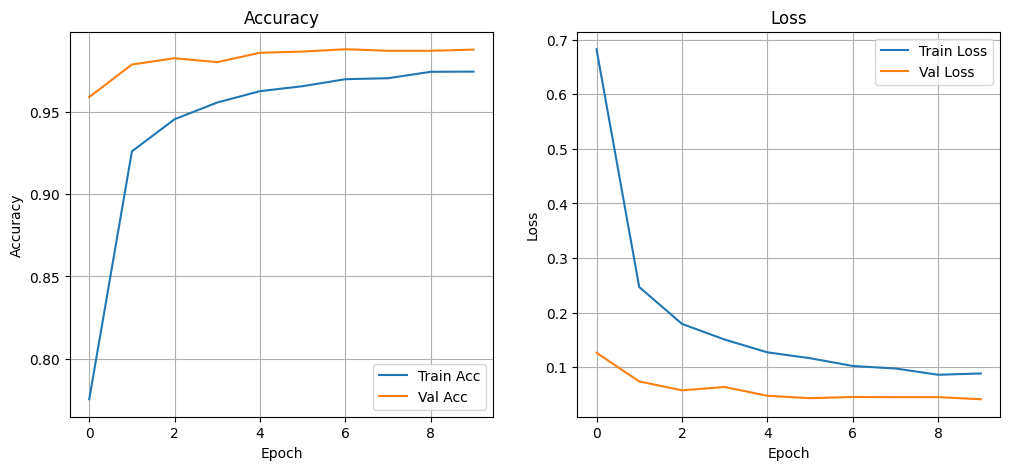

In [9]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [10]:
predictions = model.predict(test)
predicted_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


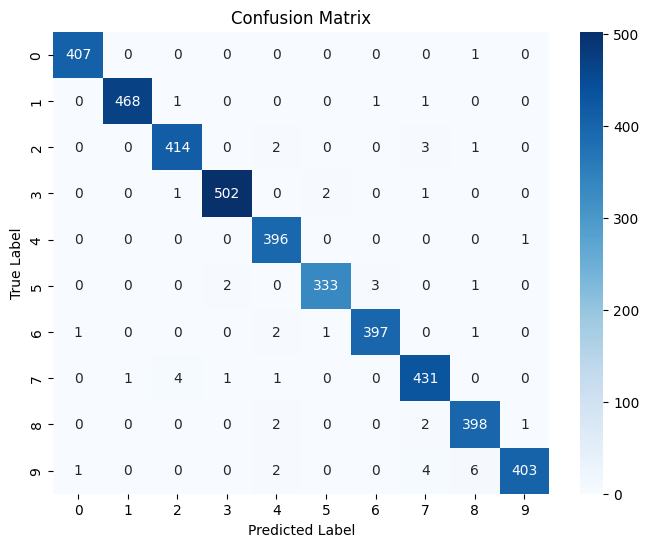

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict probabilities
predictions = model.predict(X_val)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [12]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predicted_labels)+1),
    "Label": predicted_labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file saved!")

Submission file saved!
